<a href="https://colab.research.google.com/github/sathiyapriyaprakash/Digitalportfolio/blob/main/Uber_ride_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

uber_df = pd.read_csv("/content/uberdrive.csv")
uber_df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


# **Dataset Information**

In [ ]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


# **Missing Values**

In [ ]:
uber_df.isnull().sum()

,0
START_DATE*,0
END_DATE*,1
CATEGORY*,1
START*,1
STOP*,1
MILES*,0
PURPOSE*,503


# **Shape**

In [ ]:
print("Rows and Columns:", uber_df.shape)

Rows and Columns: (1156, 7)


In [ ]:
print(uber_df.columns)

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='object')


In [ ]:
uber_df.duplicated().sum()

np.int64(1)

# **Data Preprocessing**

In [ ]:
uber_df.isnull().sum()

,0
START_DATE*,0
END_DATE*,1
CATEGORY*,1
START*,1
STOP*,1
MILES*,0
PURPOSE*,503


In [ ]:
uber_df = uber_df.dropna()

In [ ]:
uber_df.isnull().sum()

,0
START_DATE*,0
END_DATE*,0
CATEGORY*,0
START*,0
STOP*,0
MILES*,0
PURPOSE*,0


# **Convert Date**

In [ ]:
uber_df['START_DATE*'] = pd.to_datetime(uber_df['START_DATE*'],format='mixed', errors='coerce')
uber_df['END_DATE*'] = pd.to_datetime(uber_df['END_DATE*'],format='mixed', errors='coerce')

uber_df = uber_df.dropna(subset=['START_DATE*', 'END_DATE*'])

uber_df['Hour'] = uber_df['START_DATE*'].dt.hour
uber_df['Day'] = uber_df['START_DATE*'].dt.day_name()
uber_df['Month'] = uber_df['START_DATE*'].dt.month_name()

uber_df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,Hour,Day,Month
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,Friday,January
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,1,Saturday,January
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20,Saturday,January
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17,Tuesday,January
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14,Wednesday,January


# Category graph

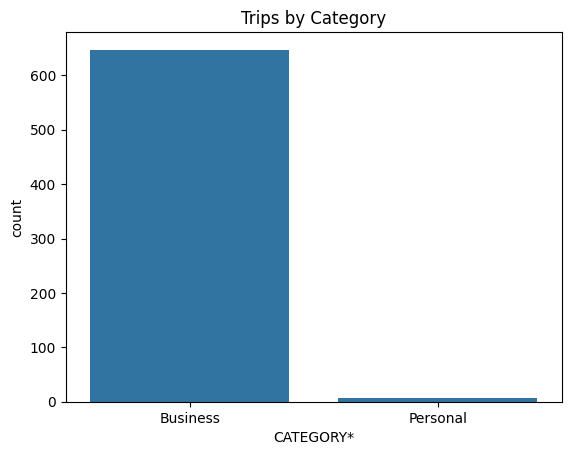

In [ ]:
sns.countplot(x='CATEGORY*', data=uber_df)
plt.title('Trips by Category')
plt.show()

# **Peak Hours Graph**

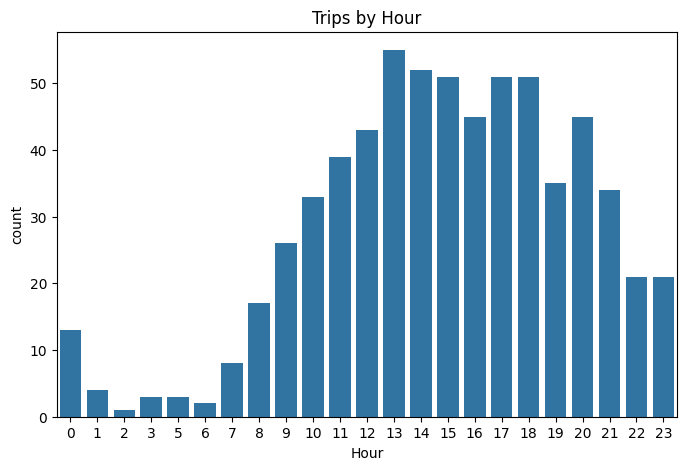

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Hour', data=uber_df)
plt.title('Trips by Hour')
plt.show()

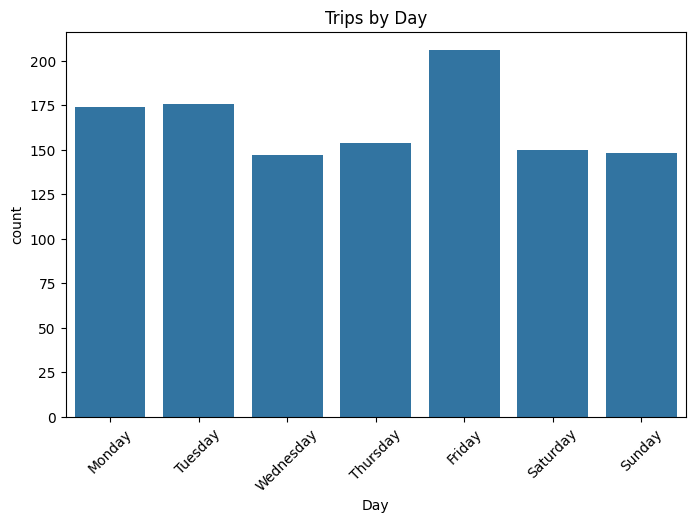

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Day', data=uber_df,order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.xticks(rotation=45)
plt.title('Trips by Day')
plt.show()

# **Trips By Month**

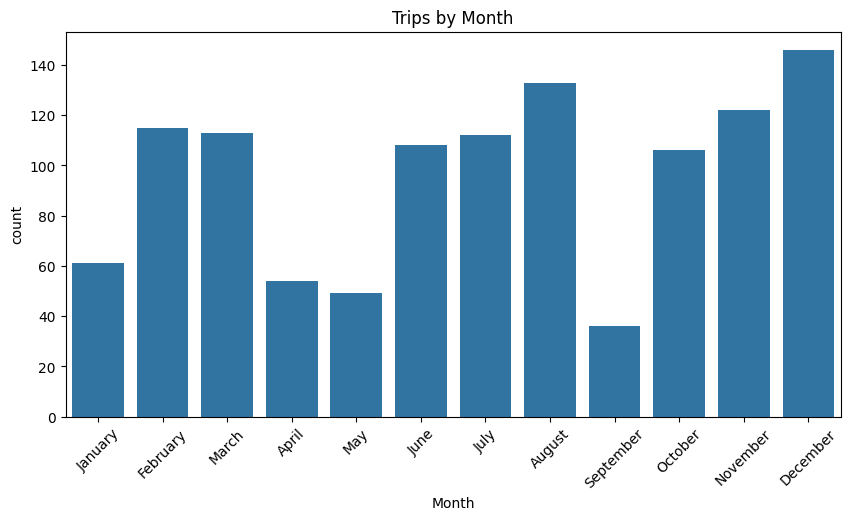

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Month', data=uber_df)
plt.xticks(rotation=45)
plt.title('Trips by Month')
plt.show()

# **Top Start Locations**

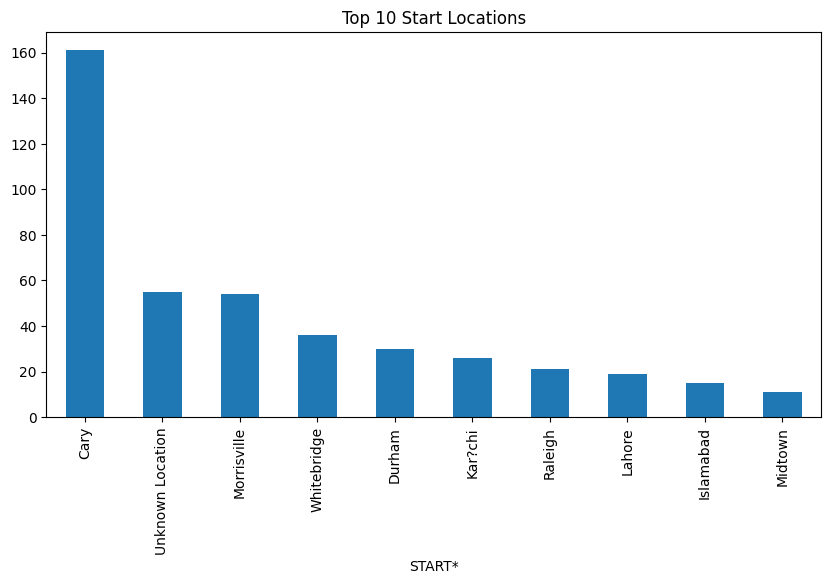

In [ ]:
plt.figure(figsize=(10,5))
uber_df['START*'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Start Locations")
plt.show()

# **Top Stop Location**

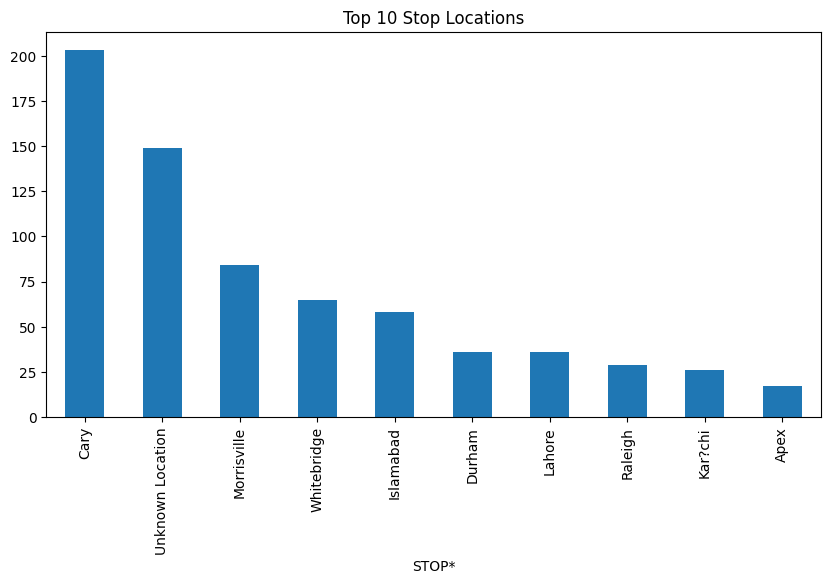

In [ ]:
plt.figure(figsize=(10,5))
uber_df['STOP*'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Stop Locations")
plt.show()

# **Top Purpose**

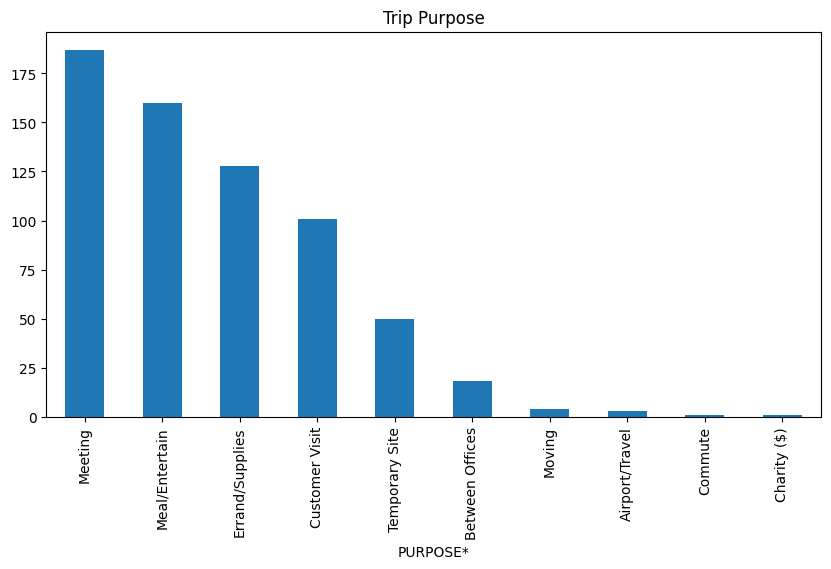

In [ ]:
plt.figure(figsize=(10,5))
uber_df['PURPOSE*'].value_counts().plot(kind='bar')
plt.title("Trip Purpose")
plt.show()

# **Histogram**

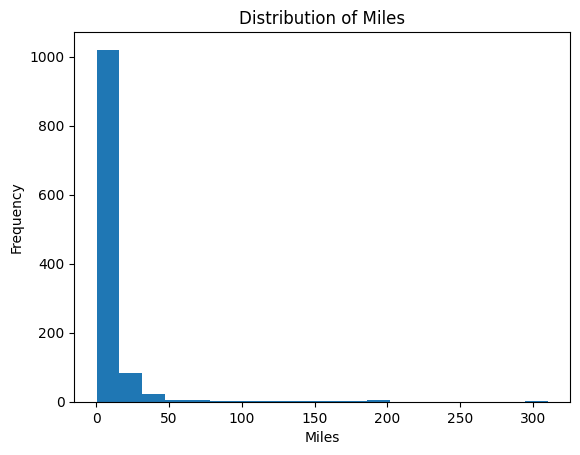

In [ ]:
plt.hist(uber_df['MILES*'], bins=20)
plt.xlabel('Miles')
plt.ylabel('Frequency')
plt.title('Distribution of Miles')
plt.show()

# **Heat Map**

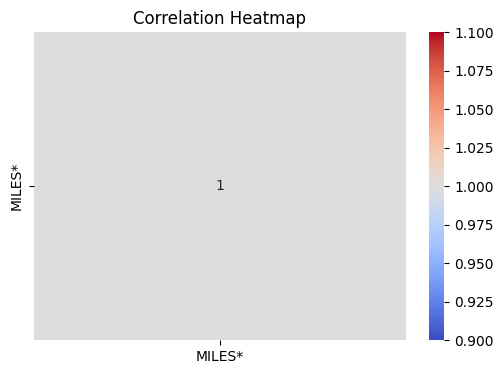

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

numeric_df=uber_df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# **Pie Chart**

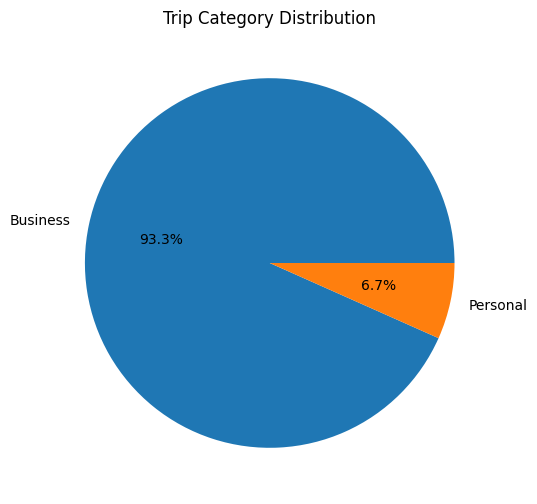

In [ ]:
plt.figure(figsize=(6,6))

uber_df['CATEGORY*'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Trip Category Distribution')
plt.ylabel("")
plt.show()

# **Box Plot**

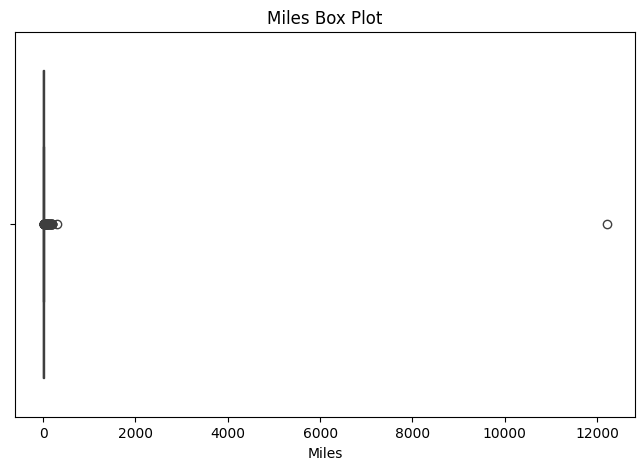

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=uber_df['MILES*'])

plt.title("Miles Box Plot")
plt.xlabel("Miles")
plt.show()

# ***Summary statistics***

In [ ]:
uber_df.describe()

,MILES*
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


# **Key Insights**

1.The DataSet was cleaned by handiling missing values and removing Duplicate Records.

2.Date and Time information was processed to Analyze Ride Patterns by Day,Month and Hour.

3.Most Uber Trips Occurred during Peak Hours, Indicating higher Ride demand at specific times.

4.The Top Start Locations accounted for the highest number of Trips.

5.Visualizations such as box plot Histograms and Heat Maps helped identifi Ride Patterns and Trends.

6.Overall the Analysis Provided usefull insights into Uber Ride Behavior and Travel patterns.


# **Conclusion**

The Uber Ride Analysis project was successfully completed using python,pandas,numpy,Matplotlib,and seaborn.Data Preprocessing,Exploratory Data Analysis(EDA),and various visualizations were preformed to understand ride patterns,peak hours,trip distibution, and Top locations.The Analysis proved meaningful Business insights that can helps improved Ride planning, driver allocation and decision-making.Overall, This project demonstrates the pratical application of data science techniques for Analyzing Real-world transportation data.